# Implementing a PID controller for altitude control

[Notebook 1 - PID Control Overview](./1-PID_control_overview.ipynb) introduced the PID controller, and
  [Notebook 2 - Flight Control Architecture](./2-flight_control_architecture_overview.ipynb) placed the altitude controller on
  the Duckiedrone. The controller fundamentally compares the altitude, measured through a time of flight sensor, with a setpoint and commands a normalized
  thrust to flight controller. 
  
In robotics, especially when managing safety-critical platforms such as a drone, it is a best practice to test things in simulation before deploying on the hardware. This is because simulation allows to:
- quickly iterate in tuning;
- get a feeling of the difference between theory and practice;
- catch any potential mistake in the implementation that could yield potentially unsafe outcomes on the physical platform. 

A lot more could be said about the use of simulation in robotics, especially with the recent advent of learning-based agents that train in simulation to get then deployed in the real world ("simulation to reality", or "sim2real" learning). At this stage, it is important to keep in mind that simulations are just models, and no matter how fancy, all models are wrong. So do not overfit your solution to the simulator, as the implementation on the real robot - and the interaction with the laws of physics - is what ultimately matters. Some roboticists like to summarize this warning with the saying: "Simulations are doomed to succeed". 

So, to get our feet wet with implementation, in this notebook we explore writing the controller in Python and testing it on a mathematical model of
  the vertical motion of a Duckiedrone, derived in [the next section](#model) and simulated in
  Python inside this notebook. The next notebook instead, [Notebook 4 - Hands on Altitude tuning](./4-hands-on-altitude-tuning.ipynb), will fly the same
  code on both virtual Duckiedrone in the Duckiematrix, and on a physical Duckiedrone.

## Intended Learning Outcomes

By the end of the notebook you should be able to answer:

- Why does the hover thrust offset $K$ alone not hold the Duckiedrone at an altitude?
- Why does a P controller oscillate around the setpoint, and what does the D term change?
- Why does a PD controller settle below the setpoint when $K$ is lower than the hover thrust,
  and how does the I term remove that error?
- Why does a measurement delay force lower gains, and why does measurement noise reach the
  thrust command mostly through the D term?

## The vertical flight model

<a id="model"></a>

The model describes a Duckiedrone that moves only along the vertical axis: the controller
  commands a normalized thrust, and the model computes how the altitude responds. The symbols
  used in the rest of this notebook are:

| Symbol | Meaning | Units |
|---|---|---|
| $h$ | Altitude above the floor | m |
| $h_{ref}$ | Altitude setpoint | m |
| $h_{measured,k}$ | Altitude the controller receives at step $k$ | m |
| $e_k$ | Tracking error at step $k$ | m |
| $e_{int,k}$ | Running total of $e \Delta t$ up to step $k$, the discrete integral of the error | m s |
| $e_{der,k}$ | Change of the error per second at step $k$, the discrete derivative of the error | m/s |
| $u$ | Normalized thrust command: 0 is no thrust, 1 is the maximum thrust of the motors | none, in $[0, 1]$ |
| $T_{max}$ | Maximum thrust of the motors | N |
| $m$ | Mass of the Duckiedrone | kg |
| $g$ | Gravitational acceleration, 9.81 | m/s^2 |
| $a$ | Vertical acceleration, positive upward | m/s^2 |
| $u_{hover}$ | Thrust at which the Duckiedrone hovers, a property of the Duckiedrone | none |
| $K$ | Hover thrust offset, the value of $u_{hover}$ written into the controller | none |
| $K_p$, $K_i$, $K_d$ | Proportional, integral and derivative gains | 1/m, 1/(m s), s/m |
| $\Delta t$ | Time between two controller steps | s |

As the motors rotate, the propellers push air in such a way to produce an upwards (in the body frame) force, which summed together across all motors, we call thrust. The command $u(t)$ sets that force as a fraction of the largest force the motors can produce ($T_{max}$), so the thrust is $u T_{max}$, and as any force, measured in Newtons. At $u = 0.5$ the motors push with half their maximum force. 

Counteracting the upwards thrust, gravity pulls the Duckiedrone down (in the world frame) with its weight, $W = m g$.

In this simplified one dimensional model, the drone's attitude is always zero, i.e., it only goes up and down - not left and right - so the body and world frames are always aligned and we do not need to distinguish between thurst: the force generated by the motors, and lift: the upwards component of thrust in the world frame. 

For convenience we define the **hover thrust** $u_{hover}$ as the command $u \in [0,1]$ at which the thrust equals the weight. 

$$ T_{hover} = u_{hover} T_{max} = m g \tag{1} $$

To obtain the equations of motion for this simple model we rely on physic's most famous formula: the first cardinal equation, which in case of a constant mass object like the Duckiedrone, simplifies to Newton's "$F = ma$", or better, $ \sum F^{(e)} = m \ddot{x}(t)$. This states that the sum of all external forces on a rigid body is equal to its mass times accelleration.  

A quick free body diagram helps us visualize this:

<figure>
    <img src="../assets/_images/pid/drone-1d-fbd-2.jpg" alt = "1D Free Body Diagram of Drone"  style="width:60%">
</figure>

The net upward force on the model is the thrust minus the weight, $u T_{max} - m g$, so applying Newton's formula:

$$ \ddot x (t) = \frac{u T_{max} - m g}{m} \tag{2} $$

Equation (2) needs $m$ and $T_{max}$, but both can be replaced using equation (1). Dividing
  equation (1) by $u_{hover}$ gives $T_{max} = m g / u_{hover}$, and putting that in place of
  $T_{max}$ in equation (2):

$$ a = \frac{u \, m g / u_{hover} - m g}{m} \tag{3} $$

Both terms of the numerator of equation (3) contain $m g$, so dividing by $m$ leaves:

$$ a = g \left( \frac{u}{u_{hover}} - 1 \right) \tag{4} $$

Equation (4) is the model. It needs only $g$ and $u_{hover} = 0.44$, the hover thrust of a
  physical Duckiedrone. At $u = u_{hover}$ the acceleration of the center of mass of the Duckiedrone is zero, any $u$ above $u_{hover}$
  accelerates the model upward, any $u$ below it downward, and the floor at $h = 0$ stops the
  fall.

The controller runs at $f = \frac{1}{\Delta T} =20 Hz$, so each step is $\Delta T = 0.05$ s. At step $k$, the controller receives the tracking error

$$ e_k = h_{ref} - h_{measured,k} \tag{5} $$

and returns a thrust, which stays constant until the next step. The measured altitude is assumed equal the true altitude ($x$) until [Activity 4](#activity-4) adds a delay and noise.

The model leaves out everything but vertical motion: it does not tilt or drift sideways, and the motors produce a new thrust the instant it is commanded (no actuator dynamics or command latency).

## Activity 1: write the PID controller

<a id="activity-1"></a>

The controller is a Python class, `PID`, in
  [`pid_class.py`](../packages/solution/solution/pid_class.py). This notebook flies it on the
  model, and Notebook 4 flies the same file on a Duckiedrone. The file already defines the
  class, its gains and its state variables. Two methods are empty, and writing them is this
  activity:

- `step(err, dt)` receives the tracking error $e_k$ of equation (5) and the time $\Delta t$
  since the previous step, and returns the thrust command $u_k$.

- `reset()` sets the state variables back to zero.

Each method contains a `TO IMPLEMENT` block that lists the lines to write, and the two sections
  below explain them. The order is:

1. Open `pid_class.py` and write `step` and `reset`, following their `TO IMPLEMENT` blocks.

2. Save the file.

3. Run the first code cell below, which loads the model.

4. Run the second code cell below, which checks the thrust commands `step` returns.

### What `step` computes

`step` implements the discrete PID controller of [Notebook 1](./1-PID_control_overview.ipynb),
  in the same notation. The integral of the error becomes a running total, updated once per
  step:

$$ e_{int,k} = e_{int,k-1} + e_k \Delta t \tag{6} $$

The derivative of the error becomes the change since the previous step, divided by the time between the two:

$$ e_{der,k} = \frac{e_k - e_{k-1}}{\Delta t} \tag{7} $$

Each term is multiplied by its gain, and the hover thrust offset is added:

$$ u_k = K_p e_k + K_i e_{int,k} + K_d e_{der,k} + K \tag{8} $$

Three parts of these equations need care in code:

- **The sum.** Equation (6) needs the total from the previous step, $e_{int,k-1}$, so the class keeps it in `self.e_int` between calls and adds $e_k \Delta t$ to it at every call.

- **The difference.** Equation (7) needs the previous error, $e_{k-1}$, so the class keeps it in `self.err`. The first call has no previous error and receives $\Delta t = 0$, so $e_{der,k}$ is set to zero there instead of dividing by zero.

- **The range.** The thrust command must lie in $[0, 1]$, so $u_k$ from equation (8) is clipped to that range before it is returned.

`self.e_int` and `self.e_der` are attributes rather than local variables because the controller node in Notebook 4 reads them to log each term separately.

### What `reset` does

`self.err`, `self.e_int` and `self.e_der` carry information from one call of `step` to the next. `reset` sets all three to zero, so that a new flight does not start with the history of the previous one. [Activity 3](#activity-3) checks it.

### Load the model and check the output

The cell below loads the model and defines the functions the rest of the notebook uses. It produces no output. Every flight loads `pid_class.py` again, so after saving a change to the file, running a flight again is enough: the notebook does not need a restart.

In [1]:
# The model and the tools that fly it. This cell defines functions and produces no plot.
import importlib
import sys
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline

# Jupyter runs the notebook from the notebooks/ folder, so the package is one level up.
EXERCISE_DIRECTORY = Path.cwd().parent / "packages" / "solution" / "solution"
sys.path.insert(0, str(EXERCISE_DIRECTORY))

import pid_class
from drone_sim import VerticalDrone

LABEL_STYLE = {"description_width": "100px"}


def new_pid(kp, ki, kd, k):
    """Load pid_class.py from disk and build a controller with these gains."""
    importlib.reload(pid_class)
    return pid_class.PID(kp=kp, ki=ki, kd=kd, k=k)


def fly(pid, setpoint, latency_ms=0, noise_m=0.0):
    """Fly the model from the floor to the setpoint for 15 s."""
    sim = VerticalDrone(
        pid,
        latency=round(latency_ms / 1000 / VerticalDrone.DT),
        sensor_noise=noise_m,
    )
    sim.update_setpoint(height=setpoint)
    sim.simulate(end_time=15.0)
    return sim


def tuner(kp=0.0, ki=0.0, kd=0.0, k=0.44, setpoint=0.5, delay_and_noise=False):
    """Show one control per input and fly again whenever a control changes."""
    gains = {
        "kp": widgets.FloatSlider(value=kp, min=0.0, max=2.0, step=0.05, description="Kp [1/m]"),
        "ki": widgets.FloatSlider(value=ki, min=0.0, max=1.0, step=0.05, description="Ki [1/(m s)]"),
        "kd": widgets.FloatSlider(value=kd, min=0.0, max=1.0, step=0.05, description="Kd [s/m]"),
        "k": widgets.FloatSlider(value=k, min=0.30, max=0.50, step=0.01, description="K"),
    }
    flight = {
        "setpoint": widgets.FloatSlider(value=setpoint, min=0.1, max=2.0, step=0.1, description="setpoint [m]"),
    }
    if delay_and_noise:
        flight["latency_ms"] = widgets.IntSlider(value=0, min=0, max=300, step=50, description="latency [ms]")
        flight["noise_m"] = widgets.FloatSlider(value=0.0, min=0.0, max=0.02, step=0.002, readout_format=".3f", description="noise [m]")

    controls = {**gains, **flight}
    for control in controls.values():
        control.style = LABEL_STYLE
        control.continuous_update = False

    def update(kp, ki, kd, k, setpoint, latency_ms=0, noise_m=0.0):
        fly(new_pid(kp, ki, kd, k), setpoint, latency_ms, noise_m).plot_step_response()

    out = widgets.interactive_output(update, controls)
    display(widgets.HBox([widgets.VBox(list(gains.values())), widgets.VBox(list(flight.values()))]), out)


def fly_twice(pid, setpoint=0.5):
    """Fly the same controller object twice and plot both altitudes."""
    first = fly(pid, setpoint).altitude_history
    second = fly(pid, setpoint)
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.axhline(setpoint, color="tab:orange", linestyle="--", label="setpoint")
    ax.plot(second.time_history, first, color="tab:blue", label="first flight")
    ax.plot(second.time_history, second.altitude_history, color="tab:red", linestyle="--", label="second flight")
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("time [s]")
    ax.set_ylabel("altitude [m]")
    ax.legend(loc="upper right")
    ax.grid(True)
    plt.show()


def check_range():
    """Fly with gains far above any tuned value and report the thrust range."""
    thrust = fly(new_pid(kp=5.0, ki=1.0, kd=2.0, k=0.44), setpoint=2.0).thrust_commands
    low, high = min(thrust), max(thrust)
    verdict = "inside [0, 1]" if 0.0 <= low and high <= 1.0 else "OUTSIDE [0, 1], check the clipping"
    print(f"Thrust commands from {low:.2f} to {high:.2f}: {verdict}")

The cell below flies the controller with gains far larger than any tuned value, so the unclipped
  $u_k$ leaves $[0, 1]$ in both directions. Every returned thrust must still lie inside the
  range.

In [2]:
check_range()

Thrust commands from 0.00 to 1.00: inside [0, 1]


## Activity 2: the effect of each term

<a id="activity-2"></a>

The tuner below flies the controller from the floor to the setpoint for 15 s. The top plot shows
  the altitude, the bottom plot the thrust command with $u_{hover}$ as a dotted line.

A gain set to zero removes its term from the control law, so each term can be studied on its
  own. The tuner starts with every gain at zero, $K = 0.44$, and the setpoint at 0.5 m.

In [3]:
tuner()

Output()

Each step below changes one control. Predict what the plots will do before moving it.

1. **The hover thrust offset alone.** With every gain at zero, equation (8) reduces to $u_k = K$
   at every step, whatever the altitude. At $K = 0.44$ equation (4) gives zero acceleration and
   the model stays on the floor. Raise $K$ to $0.45$: the model accelerates upward, passes the
   setpoint without slowing, and leaves the plot at $2.5 m$ after about $5 s$. No term depends on
   the error, so nothing stops it. Return $K$ to $0.44$.

2. **The $P$ term.** Set $K_p$ to $1.0$. The model climbs to about $1.1 m$, falls back to the floor,
   and repeats. The $P$ term pushes toward the setpoint in proportion to the distance from it, but
   nothing slows the model as it approaches, so it arrives with speed and overshoots. Raise
   $K_p$ to $2.0$: the oscillation becomes faster, not smaller. Return $K_p$ to $1.0$.

3. **The $D$ term.** Keep $K_p = 1.0$ and set $K_d$ to 0.1. The oscillation now decays: the model
   overshoots to about $0.8 m$ and settles in about $3.5 s$. The $D$ term opposes changes of the
   error, so it brakes the model as it approaches the setpoint. At $K_d = 0.4$ the model reaches
   $0.5 m$ in about $1 s$ without overshooting. At $K_d = 1.0$ it still does not overshoot but
   approaches more slowly, because the braking is now stronger than needed. Set $K_d$ back to
   $0.4$.

4. **A wrong hover thrust offset.** $K$ is only as good as the value of $u_{hover}$ written into
   the controller, and Notebook 4 shows that it differs between a virtual and a physical
   Duckiedrone. Lower $K$ to 0.40. The model settles at 0.46 m, 4 cm below the setpoint.
   Hovering takes $u_k = 0.44$, and the only term that can add the missing 0.04 is the P term,
   which needs $K_p e_k = 0.04$, an error of 0.04 m. Raise $K_p$ to 2.0: the error halves to 2
   cm but does not vanish. Return $K_p$ to 1.0.

5. **The $I$ term.** Keep $K = 0.40$ and set $K_i$ to 0.3. The model now settles at 0.5 m. The I
   term keeps growing as long as any error remains, so it grows until it supplies the missing
   0.04 and the error is zero. At $K_i = 1.0$ it grows faster and overshoots to about 0.58 m
   before settling. Return $K_i$ to 0.3.

The three terms react to different things: the $P$ term to the present error, the $D$ term to how
  fast the error changes, and the $I$ term to the error accumulated so far.

## Activity 3: check the reset

<a id="activity-3"></a>

`self.e_int` and `self.err` survive from one call of `step` to the next. When the controller
  starts a new flight, both must start again from zero, or the first commands of the new flight
  carry the history of the previous one. The simulation calls `reset()` at the start of every
  flight, and the controller node in Notebook 4 calls it whenever the Duckiedrone is armed and
  whenever altitude control is enabled.

The cell below flies one `PID` object twice, with $K = 0.35$ so that the $I$ term has to supply
  0.09 of thrust. With `reset` written, the second flight repeats the first and the two curves
  overlap. Without it, the second flight starts with the sum left over from the first,
  overshoots to about $0.56 m$, and settles about three times more slowly.

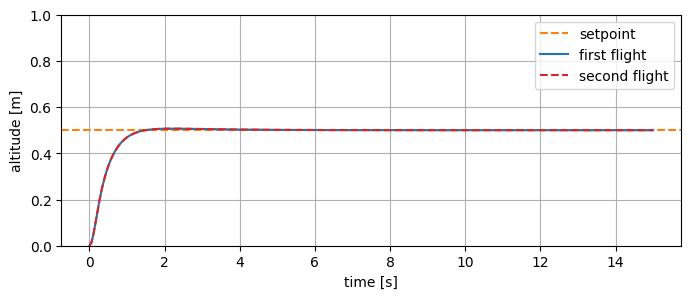

In [4]:
fly_twice(new_pid(kp=1.0, ki=0.5, kd=0.4, k=0.35))

## Activity 4: measurement delay and noise

<a id="activity-4"></a>

So far the controller has received the true altitude at every step.
  [Notebook 1](./1-PID_control_overview.ipynb) explained why a measured value is neither current
  nor exact: it arrives with a delay, and it carries noise. The tuner below adds both to the
  model:

- `latency [ms]` delays the altitude the controller receives, in steps of 50 ms, one controller
  step.

- `noise [m]` adds to every measurement a random value drawn from a normal distribution with
  zero mean and this standard deviation. The same random values are drawn at every flight, so
  moving another control does not change the noise.

The measured altitude appears as gray points. The tuner starts from the gains Activity 2 arrived
  at with the correct $K$: $K_p = 1.0$, $K_i = 0$, $K_d = 0.4$, $K = 0.44$, with no delay and no
  noise.

In [5]:
tuner(kp=1.0, kd=0.4, delay_and_noise=True)

Output()

Each step below changes one control. Predict what the plots will do before moving it.

1. **A delay.** Set `latency [ms]` to $50$: the model still settles in about $1 s$. At $100 ms$ it no
   longer settles and keeps oscillating between about $0.37$ and $0.67 m$. The controller now acts
   on where the model was $100 ms$ earlier, so its braking arrives too late. At $200 ms$ the model
   swings from the floor to about $1.5 m$.

2. **Lower gains.** Set `latency [ms]` back to $100$, and lower $K_p$ to $0.5$ and $K_d$ to $0.3$. The
   model settles in about $2 s$ without overshooting: smaller corrections change the altitude
   slowly enough for a measurement $100 ms$ old to be close to the truth. At $200 ms$ these gains
   oscillate again, and $K_p = K_d = 0.2$ is needed to settle, in about $3 s$. The longer the
   delay, the lower the gains and the slower the controller. Set `latency [ms]` to $0$, $K_p$ to
   $1.0$ and $K_d$ to $0.4$.

3. **Noise.** Set `noise [m]` to $0.010$. The altitude stays within $2 cm$ of the setpoint, but
   after it settles the thrust command jumps between about $0.06$ and $0.78$ from one step to the
   next. The $D$ term divides the difference of two noisy measurements by $\Delta t = 0.05 s$, so
   noise of $1 cm$ becomes derivative changes of about $\sqrt{2} \cdot 0.01 / 0.05 \approx 0.28
   m/s$. Lower $K_d$ to $0.2$: the thrust stays between about $0.24$ and $0.63$, at the cost of an
   overshoot to about $0.6 m$. For scale, the downward rangefinder of a physical Duckiedrone
   resting on the floor returns readings that vary by about $2 mm$.

4. **Both.** Set `latency [ms]` to $100$ and `noise [m]` to $0.010$, and find gains with which the
   model settles at the setpoint without climbing above $0.55 m$.

## Summary and next steps

The class `PID` in `pid_class.py` now makes the modeled drone hover stably and with ok performance. With exact measurements,
  the $P$ and $D$ terms together reach the setpoint without overshooting, and the $I$ term removes the
  error a wrong $K$ leaves behind. A measurement delay forces lower gains, and measurement noise
  reaches the thrust command mostly through the $D$ term.

Every one of these results depends on numbers the model fixed: $u_{hover} = 0.44$, a thrust that
  follows the command instantly, and the delay and noise chosen above. On a Duckiedrone these
  numbers are measured rather than chosen, so [Notebook 4](./4-hands-on-altitude-tuning.ipynb)
  flies the same class and tunes its gains again.

## Thinking activities

Before moving on to the next notebook, stop a second and reflect:

- Do you expect this PID tuning to work on the virtual Duckiedrone, in the Duckiematrix? Why or why not?
- Similarly, do you expect this PID tuning to work on the physical Duckiedrone? Why or why not?